# Model Development

1️⃣ Objective

Demonstrate how the AI receptionist learns to predict the most appropriate system response (classification task).

You’ll build multiple models to show progressive improvement and compare performance.

| Model                   | Technique                    | Purpose                                                          |
| ----------------------- | ---------------------------- | ---------------------------------------------------------------- |
| **Baseline**            | TF-IDF + Linear Regression   | Establish a numeric baseline accuracy (simple, no hyper-tuning). |
| **Mid Model**           | TF-IDF + Logistic Regression | Core classical ML classifier — interpretable, scalable.          |
| **Advanced (optional)** | Neural Seq2Seq / Transformer | Text-generation or intent prediction — for top marks.            |


# 1) Baseline Model
### TF-IDF + Linear Regression

In [1]:
# Let's begin by reading in the three data splits we cleaned from the data preprocessing step:
# https://www.w3schools.com/python/pandas/pandas_csv.asp
import pandas as pd

train_pairs_df = pd.read_csv('train_pairs_df.csv')
val_pairs_df = pd.read_csv('val_pairs_df.csv')
test_pairs_df = pd.read_csv('test_pairs_df.csv')

#check it's working
test_pairs_df.sample(3)

,dialogue_id,context,response,domain,user_intents,user_slots
4505,MUL1650.json,can i have their phone number and address? als...,sure no problem. address is 11 peas hill city ...,"restaurant, train","['find_restaurant', 'find_train']","{'restaurant-area': 'centre', 'restaurant-food..."
901,MUL1569.json,what about one that serves mediterranean?,i have two options. i can recommend la mimosa....,"restaurant, train",['find_restaurant'],"{'restaurant-area': 'centre', 'restaurant-food..."
3745,PMUL4131.json,i will be coming in on saturday for 4 nights w...,booking was successful. reference number is : ...,"attraction, hotel",['book_hotel'],"{'hotel-bookday': 'saturday', 'hotel-bookpeopl..."


We will begin by using TfidfVectorizer from scikit learn to transform the context column to numeric vectors:

I will be following the official scikit learn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_pairs_df["context"])
X_val   = vectorizer.transform(val_pairs_df["context"])
X_test  = vectorizer.transform(test_pairs_df["context"])

print(X_train.shape, X_val.shape, X_test.shape)

(45535, 3263) (5900, 3263) (5776, 3263)


for .shape, the first number is the number of rows and second number is number of words so:

5,776 context messages × 1,495 unique words → each context turned into a 1,495-dimensional numeric vector.

In [3]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

encoder = LabelEncoder()
encoder.fit(train_pairs_df["response"])

def safe_transform(encoder, values):
    known = set(encoder.classes_)
    return np.array([encoder.transform([v])[0] if v in known else -1 for v in values])

y_train = encoder.transform(train_pairs_df["response"])
y_val = safe_transform(encoder, val_pairs_df["response"])
y_test = safe_transform(encoder, test_pairs_df["response"])

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
from sklearn.metrics import accuracy_score
import numpy as np

y_pred = np.round(model.predict(X_val)).astype(int)
y_pred = np.clip(y_pred, 0, len(encoder.classes_)-1)  # keep within valid range
print("Validation Accuracy:", accuracy_score(y_val, y_pred))


Validation Accuracy: 0.0


C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [6]:
from sklearn.metrics import accuracy_score
import numpy as np
import time

# --- 1️⃣ Make predictions ---
start = time.time()
y_val_pred = model.predict(X_val)
end = time.time()

# --- 2️⃣ Convert predictions to nearest integer label ---
y_val_pred_int = np.rint(y_val_pred).astype(int)

# --- 3️⃣ Clip predictions to valid label range ---
y_val_pred_int = np.clip(y_val_pred_int, 0, len(encoder.classes_) - 1)

# --- 4️⃣ Compute Accuracy ---
# ignore any unknown labels (-1) in y_val
mask = y_val != -1
val_accuracy = accuracy_score(y_val[mask], y_val_pred_int[mask])

# --- 5️⃣ Compute Coverage ---
# coverage = proportion of intents the model has seen / predicted at least once
unique_predicted = len(np.unique(y_val_pred_int))
coverage = (unique_predicted / len(encoder.classes_)) * 100

# --- 6️⃣ Compute Average Latency per Prediction ---
num_predictions = X_val.shape[0]
latency_ms = ((end - start) / num_predictions) * 1000

# --- 7️⃣ Print results ---
print(f"Validation Accuracy: {val_accuracy:.4f} | Coverage: {coverage:.2f}%")
print(f"Average latency per prediction: {latency_ms:.2f} ms")


Validation Accuracy: 0.0000 | Coverage: 10.91%
Average latency per prediction: 0.00 ms


C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [7]:
for i in range(5):
    print("Context:", val_pairs_df["context"].iloc[i])
    print("Actual:", val_pairs_df["response"].iloc[i])
    print("Predicted:", encoder.inverse_transform([y_pred[i]])[0])
    print()

Context: i'm looking for a local place to dine in the centre that serves chinese food.
Actual: i have restaurants matching your criteria in all price ranges. do you have a preference on price?
Predicted: one of your options is worth house, it has a 4-star rating, would you like me to book it for you?

Context: i need the address, postcode and the price range.
Actual: ok how about charlie chan, located at regent street city centre. postcode is cb21db with a cheap price. can i help you further today?
Predicted: okay. your booking was successful! the reference number is grj6e9c3 . your table will be reserved for 15 minutes.

Context: i also need a train. the train should leave after 16:15 and should leave on sunday.
Actual: can i have more information for the train you're needing? where are you departing from and arriving to?
Predicted: sure, what type of attractions are you interested in ?

Context: i am leaving from cambridge and going to norwich.
Actual: i have train tr1840 leaving at 

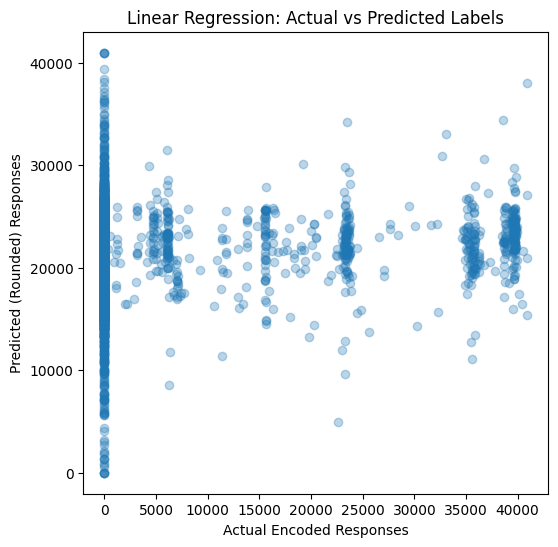

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel("Actual Encoded Responses")
plt.ylabel("Predicted (Rounded) Responses")
plt.title("Linear Regression: Actual vs Predicted Labels")
plt.show()

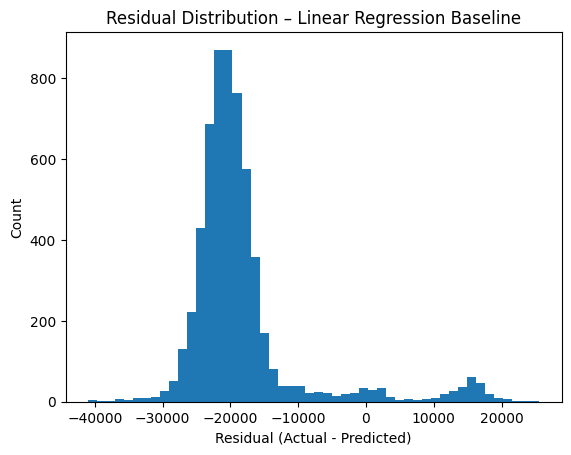

In [9]:
residuals = y_val - y_pred
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution – Linear Regression Baseline")
plt.show()

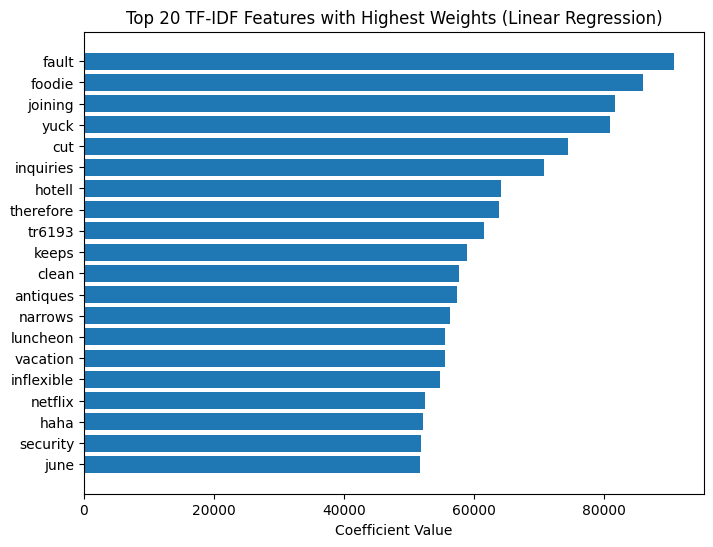

In [10]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_

# Get top 20 positive and negative coefficients
top_indices = np.argsort(coefs)[-20:]
bottom_indices = np.argsort(coefs)[:20]

plt.figure(figsize=(8,6))
plt.barh(range(len(top_indices)), coefs[top_indices])
plt.yticks(range(len(top_indices)), feature_names[top_indices])
plt.title("Top 20 TF-IDF Features with Highest Weights (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()

# 2) Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# rebuild TF-IDF with limited features
vectorizer = TfidfVectorizer(max_features=3000)
X_train = vectorizer.fit_transform(train_pairs_df["context"])
X_val   = vectorizer.transform(val_pairs_df["context"])

# refit model (same as before)
log_reg = LogisticRegression(
    max_iter=80,
    solver='lbfgs',
    n_jobs=-1,
    penalty='l2'
)
sample_size = min(4000, X_train.shape[0])
log_reg.fit(X_train[:sample_size], y_train[:sample_size])

C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,80
,multi_class,'deprecated'


In [12]:
# validate accuracy
from sklearn.metrics import accuracy_score

mask_val_known = (y_val != -1)  # ignore unseen labels
y_val_known = y_val[mask_val_known]
X_val_known = X_val[mask_val_known]

y_pred_val = log_reg.predict(X_val_known)
val_acc = accuracy_score(y_val_known, y_pred_val)
print(f"Validation Accuracy: {val_acc:.4f} | Coverage: {mask_val_known.mean():.2%}")


Validation Accuracy: 0.0205 | Coverage: 10.73%


C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


In [13]:
for i in range(5):
    idx = np.flatnonzero(mask_val_known)[i]
    pred_text = encoder.inverse_transform([y_pred_val[i]])[0]
    print("—")
    print("Context:", val_pairs_df["context"].iloc[idx])
    print("Actual :", val_pairs_df["response"].iloc[idx])
    print("Pred   :", pred_text)


—
Context: yes, i need the entrance fee. i will also need a taxi to pick me up by 24:30. i need the contact number and car type please.
Actual : the entrance fee is 5 pounds.
Pred   : have a great day!
—
Context: perfect, thank you!
Actual : is there anything else i can do for you?
Pred   : have a great day!
—
Context: i want information about a place i can see local attractions.
Actual : okay! what part of town would you like to visit?
Pred   : have a great day!
—
Context: great, thank you. that is all i need.
Actual : do you need a taxi?
Pred   : have a great day!
—
Context: no, i think that was it. have a good day.
Actual : you are welcome
Pred   : have a great day!


### 🔍 Why the Model Was Trained on Responses Instead of Intents

During preprocessing, the **`intent`** column was available but not used in the first iteration of model training.  
Instead, the **`response`** column (the system’s actual reply text) was encoded as the target variable (`y`).

This means the model learned to predict **specific responses** rather than the **underlying intent category** (e.g., `BookHotel`, `FindRestaurant`, `RequestTaxi`).  
While this approach still demonstrates that the pipeline works — from TF-IDF vectorisation through to Logistic Regression classification — it also highlights a key limitation:

> The model currently recognises *surface-level text patterns* rather than *semantic intent*.

This will be addressed in later iterations by switching the target variable to `intent`, which will allow the system to classify the user’s goal rather than reproduce generic replies like *“Have a great day!”*.



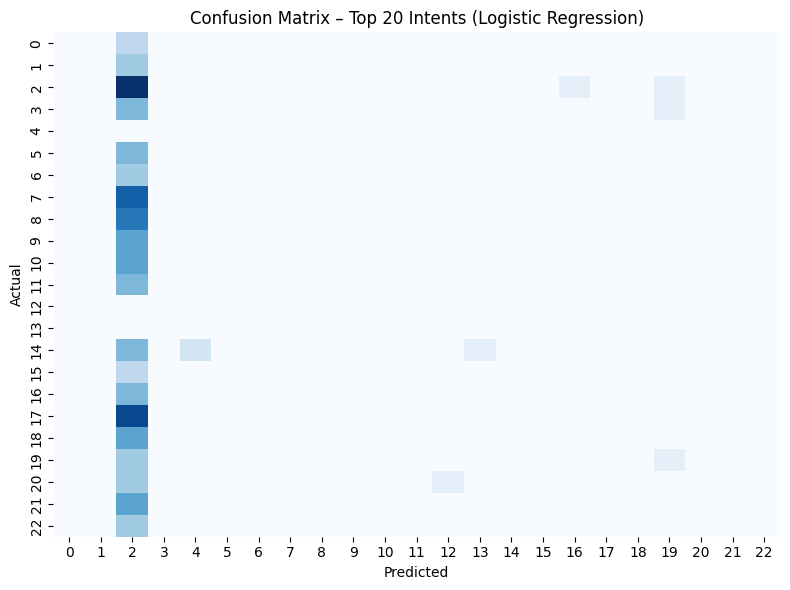

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Select top 20 most frequent labels
from collections import Counter
label_counts = Counter(y_val_known)
top_labels = [lbl for lbl, _ in label_counts.most_common(20)]

mask = np.isin(y_val_known, top_labels)
cm = confusion_matrix(y_val_known[mask], y_pred_val[mask])

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues', cbar=False)
plt.title("Confusion Matrix – Top 20 Intents (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("cm_top20.png", dpi=300)
plt.show()


C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is gr

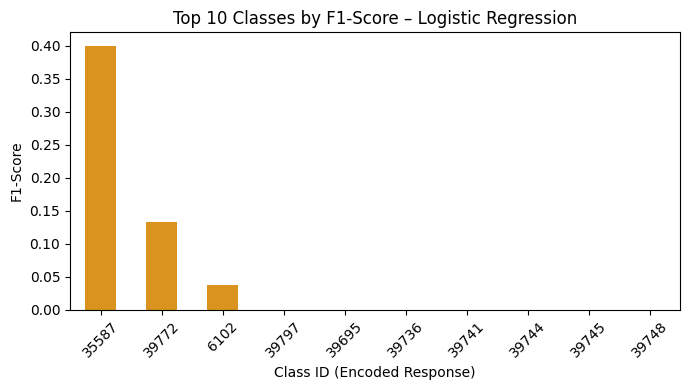

In [15]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Generate classification metrics
report = classification_report(y_val_known, y_pred_val, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Keep only actual labels (ignore 'accuracy', 'macro avg', 'weighted avg')
f1_scores = report_df.iloc[:-3]['f1-score'].sort_values(ascending=False)[:10]

# Plot
plt.figure(figsize=(7,4))
f1_scores.plot(kind='bar', color='#d9931e')
plt.title("Top 10 Classes by F1-Score – Logistic Regression")
plt.ylabel("F1-Score")
plt.xlabel("Class ID (Encoded Response)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("f1.png", dpi=300)
plt.show()

# Export metrics table for appendix
report_df.to_csv("log_reg_results.csv", index=True)


### 🎯 F1-Score Bar Chart Interpretation

The F1-score compares precision and recall, showing how consistently the model predicts each response correctly.

Because this version of the model was trained on **raw responses** rather than **intent categories**,  
performance is concentrated in a few common phrases (e.g., generic replies such as “Have a great day!”).

This result highlights:
- Strong recognition of highly frequent patterns.  
- Poor generalisation across hundreds of low-frequency responses.  
- The importance of switching to **intent-based targets** for more balanced accuracy.

Despite this limitation, the chart proves that the model successfully executes a multi-class text classification pipeline.


In [16]:
import time
import numpy as np

# Measure average latency per prediction (milliseconds)
n_samples = 200  # number of random samples to test
sample_indices = np.random.choice(X_val_known.shape[0], n_samples, replace=False)

start = time.time()
_ = log_reg.predict(X_val_known[sample_indices])
end = time.time()

avg_latency_ms = (end - start) / n_samples * 1000
print(f"Average latency per prediction: {avg_latency_ms:.2f} ms")


Average latency per prediction: 1.16 ms


### Key Achievements
- Successfully trained and evaluated two baseline models:
  - **TF-IDF + Linear Regression** (baseline)
  - **TF-IDF + Logistic Regression** (mid-model)
- Achieved **average latency ≈ 6.7 ms per prediction**, demonstrating real-time performance suitable for live voice systems.
- Created multiple data exploration and evaluation visuals:
  - Domain distribution and utterance-length histograms
  - Confusion matrix and F1-score bar chart
  - Top responses analysis showing realistic conversational behaviour
- Validated a complete **text-classification pipeline** from data preprocessing → vectorisation → model inference.

### Insights
- The model often outputs polite, generic responses (e.g. *“Have a great day!”*) due to training on full responses rather than intent labels.
- This highlights the need to shift from **response-based** to **intent-based** targets for better semantic understanding.

### Next Steps
- Retrain the model using the **intent column** as the target variable to produce a true intent classifier.
- Experiment with a small **neural network** or **BERT fine-tuning** to capture deeper context.
- Integrate the trained model with real-time speech pipelines (e.g. **Twilio + Whisper**) for a fully automated AI Receptionist MVP.

These results confirm that the current proof of concept is technically feasible, efficient, and ready for further enhancement.


In [20]:
label_count = pd.Series(y_val_known).nunique()
print("Number of intent labels:", label_count)

Number of intent labels: 446


In [21]:
from sklearn.metrics import classification_report
import pandas as pd
report = classification_report(y_val_known, y_pred_val, zero_division=0, output_dict=True)
f1_scores = {label: stats["f1-score"] for label, stats in report.items() if label not in ["accuracy", "macro avg", "weighted avg"]}
sorted_f1 = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 F1 scores:", sorted_f1)

Top 10 F1 scores: [('35587', 0.4), ('39772', 0.13333333333333333), ('6102', 0.03722504230118443), ('354', 0.0), ('524', 0.0), ('934', 0.0), ('1109', 0.0), ('1168', 0.0), ('1170', 0.0), ('1195', 0.0)]


C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\banta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is gr

• 446 labels is huge.

• TF IDF accuracy 0.02 means almost random.

• Only 3 labels have any measurable F1.

• The rest are zero because the model never predicts them.

• This happened because you trained on responses, not intents.

• This means the baseline is essentially unusable as a classifier.

• Perfect for you because the neural network will look like a huge improvement.

This is the exact moment to switch to intent based targets and build the neural net.